# Medical Sound Classification -> LSTM, Bidirectioneel LSTM en 1D CNN

In [7]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import scipy.signal
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Model

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import joblib

## 1. Data laden

Voor we kunnen beginnen moeten we natuurlijk de data laden, hier mogen we zeker niet vergeten de preprocessing stappen van het vorige notebook.

In [8]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

df_train['coldPresent_missing'] = df_train['coldPresent'].isna().astype(int)
df_train['coldPresent'] = df_train['coldPresent'].fillna(0)

print(f"train samples: {len(df_train)}")
print(df_train['disease'].value_counts())

train samples: 545
disease
1    238
2    167
0    140
Name: count, dtype: int64


## 2. YAMNet laden

In [9]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet geladen.")

YAMNet geladen.


## 3. Embedding extractie

Hier zullen we het een klein beetje anders doen, hier zullen we namelijk onze embeddings niet aggregaten omdat we voor LSTM juist de informatie doorheen de tijd nodig hebben. Moesten we dit toch doen zouden we belangrijke informatie verliezen.

In [10]:
def extract_embeddings_sequence(waveform):
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return embeddings.numpy()

## 4. Dataset bouwen

We bouwen twee datasets:
- `X_audio`: tijdreeks embeddings -> voor LSTM
- `X_meta`: metadata features -> apart gecombineerd

We zullen hier dus de verschillende segmenten gebruiken om zo meer data te gebruiken. Ieder segment krijgt ook steeds de metadata mee.

In [11]:
META_COLS = ['age', 'gender', 'tbContactHistory', 'wheezingHistory',
             'phlegmCough', 'familyAsthmaHistory', 'feverHistory',
             'coldPresent', 'packYears', 'coldPresent_missing']

df_filled = df_train.fillna(0)

X_audio  = []  # tijdreeks embeddings    
X_meta = []  # metadata
y_list = []  # labels

skipped = 0

for _, row in df_filled.iterrows():
    cid     = row['candidateID']
    disease = row['disease']
    meta    = row[META_COLS].values.astype(np.float32)
    
    # --- Cough segmenten ---
    seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
    if os.path.exists(seg_folder):
        for fname in os.listdir(seg_folder):
            if fname.endswith("_processed.wav"):
                fp = os.path.join(seg_folder, fname)
                try:
                    waveform, sr = librosa.load(fp, sr=16000)
                    emb_seq = extract_embeddings_sequence(waveform)
                    X_audio.append(emb_seq)
                    X_meta.append(meta)
                    y_list.append(disease)
                except Exception as e:
                    print(f"Fout bij {fp}: {e}")
                    skipped += 1

X_audio  = np.array(X_audio,  dtype=np.float32)   # (samples, MAX_FRAMES, 1024)
X_meta = np.array(X_meta, dtype=np.float32)   # (samples, n_meta)
y_arr  = np.array(y_list)

print(f"X_audio shape : {X_audio.shape}")
print(f"X_meta shape: {X_meta.shape}")
print(f"Labels shape: {y_arr.shape}")
print(f"Overgeslagen : {skipped}")

X_audio shape : (8317, 4, 1024)
X_meta shape: (8317, 10)
Labels shape: (8317,)
Overgeslagen : 0


In [12]:
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)


le = LabelEncoder()
y_encoded = le.fit_transform(y_arr)
num_classes = len(le.classes_)
print(f"Klassen: {le.classes_}  ({num_classes} klassen)")

# Hier splitsen we de data maar houden we onze x_audio en x_meta apart, zodat we ze later als aparte inputs kunnen gebruiken in het model.
split = train_test_split(
    X_audio,
    X_meta_scaled,
    y_encoded,
    test_size=0.2,
    random_state=1234,
    stratify=y_encoded
)

X_audio_train, X_audio_val, X_meta_train, X_meta_val, y_train, y_val = split

y_train_onehot = to_categorical(y_train, num_classes)
y_val_onehot   = to_categorical(y_val,   num_classes)

print(f"Training  : {len(X_audio_train)} samples")
print(f"Validatie : {len(X_audio_val)} samples")

Klassen: [0 1 2]  (3 klassen)
Training  : 6653 samples
Validatie : 1664 samples


## 5. Modellen

We bouwen drie varianten en vergelijken ze:

| Model | Beschrijving |
|-------|--------------|
| **LSTM** | Unidirectionele LSTM over tijdreeks + metadata |
| **BiLSTM** | Bidirectionele LSTM (kijkt ook achteruit) + metadata |
| **1D CNN** | Convoluties over de tijdas (sneller, stabiel bij kleine data) + metadata |

Om de modellen te maken zullen we iets gebruiken dat late fusion noemt. We trainen eerst onze audio en metadata tak apart om ze daarna samen te voegen.

### 5.1 LSTM

We zullen beginnen met een standaard LSTM model.

In [ ]:
def fit_model_LSTM(window_size_audio=4, window_size_meta=10):
    # audio tak
    audio_input = layers.Input(shape=(window_size_audio, 1024)) #onze audio files zijn steeds 4 frames van 1024 features (YAMNet embeddings)
    
    audio_features = layers.LSTM(128, return_sequences=True)(audio_input) 
    audio_features = layers.Dropout(0.3)(audio_features) 
    audio_features = layers.LSTM(64)(audio_features)
    audio_features = layers.Dropout(0.3)(audio_features)
    
    # metadata tak
    meta_input = layers.Input(shape=(window_size_meta,)) # Er zijn 10 metadata features
    
    meta_features = layers.Dense(32, activation='relu')(meta_input)
    meta_features = layers.Dropout(0.2)(meta_features)
    
    # beide takken combineren
    combined = layers.concatenate([audio_features, meta_features])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(3, activation='softmax')(out) # We hebben 3 mogelijke resultaten.
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer="adam", 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # training
    early_stop = EarlyStopping(
        monitor='val_loss', #We monitoren hier op val_loss omdat dit precieser is.
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_audio_train, X_meta_train], y_train_onehot,
        validation_data=([X_audio_val, X_meta_val], y_val_onehot),
        epochs= 60,
        batch_size= 16,
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_audio_val, X_meta_val], y_val_onehot, verbose=0) 
    y_pred = np.argmax(model.predict([X_audio_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"-LSTM - Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return model, history, val_acc, macro_f1, y_pred

In [14]:
lstm_model, hist_lstm, acc_lstm, f1_lstm, pred_lstm = fit_model_LSTM() 

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7511 - loss: 0.6179 - val_accuracy: 0.8263 - val_loss: 0.4357
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8151 - loss: 0.4788 - val_accuracy: 0.8462 - val_loss: 0.3976
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8285 - loss: 0.4427 - val_accuracy: 0.8630 - val_loss: 0.3678
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8395 - loss: 0.4184 - val_accuracy: 0.8642 - val_loss: 0.3513
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8479 - loss: 0.3951 - val_accuracy: 0.8738 - val_loss: 0.3361
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8455 - loss: 0.3871 - val_accuracy: 0.8744 - val_loss: 0.3271
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8525 - loss: 0.3816 - val_accuracy: 0.8732 - val_loss: 0.3282
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8528 - loss: 0.3664 - val_accuracy: 0.

### 5.2 Bidirectional LSTM

Nu zullen we een bidirectionaal model proberen.

In [15]:
def fit_model_BiLSTM(window_size_audio=4, window_size_meta=10): 
    # audio tak
    audio_input = layers.Input(shape=(window_size_audio, 1024))
    
    audio_features = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(audio_input)
    audio_features = layers.Dropout(0.3)(audio_features)
    audio_features = layers.Bidirectional(layers.LSTM(64))(audio_features)
    audio_features = layers.Dropout(0.3)(audio_features)
    
    # metadata tak
    meta_input = layers.Input(shape=(window_size_meta,)) 
    meta_features = layers.Dense(32, activation='relu')(meta_input)
    meta_features = layers.Dropout(0.2)(meta_features)
    
    # beide takken combineren
    combined = layers.concatenate([audio_features, meta_features])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(3, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer="adam", 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


    # training
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_audio_train, X_meta_train], y_train_onehot,
        validation_data=([X_audio_val, X_meta_val], y_val_onehot),
        epochs= 60,
        batch_size= 16,
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_audio_val, X_meta_val], y_val_onehot, verbose=0)
    y_pred = np.argmax(model.predict([X_audio_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"-BiLSTM - Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return model, history, val_acc, macro_f1, y_pred

In [16]:
bilstm_model, hist_bilstm, acc_bilstm, f1_bilstm, pred_bilstm = fit_model_BiLSTM()

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7367 - loss: 0.6473 - val_accuracy: 0.8221 - val_loss: 0.4733
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8093 - loss: 0.4895 - val_accuracy: 0.8425 - val_loss: 0.4099
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8241 - loss: 0.4545 - val_accuracy: 0.8600 - val_loss: 0.3799
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8422 - loss: 0.4260 - val_accuracy: 0.8684 - val_loss: 0.3602
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8431 - loss: 0.4065 - val_accuracy: 0.8684 - val_loss: 0.3439
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8437 - loss: 0.3933 - val_accuracy: 0.8690 - val_loss: 0.3367
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8512 - loss: 0.3727 - val_accuracy: 0.8810 - val_loss: 0.3134
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8575 - loss: 0.3537 - val_acc

### 5.3 1D CNN

Omdat we niet zo veel data hebben is het een keer interessant om een 1D CNN model te proberen.

In [17]:
def fit_model_1DCNN(window_size_audio=4, window_size_meta=10):
    # Audio tak 
    audio_input = layers.Input(shape=(window_size_audio, 1024))
    
    audio_features = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(audio_input)
    audio_features = layers.BatchNormalization()(audio_features)
    audio_features = layers.MaxPooling1D(pool_size=2)(audio_features)
    audio_features = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(audio_features)
    audio_features = layers.BatchNormalization()(audio_features)
    audio_features = layers.GlobalAveragePooling1D()(audio_features)
    audio_features = layers.Dropout(0.4)(audio_features)
    
    # Metadata tak 
    meta_input = layers.Input(shape=(window_size_meta,))
    meta_features = layers.Dense(32, activation='relu')(meta_input)
    meta_features = layers.Dropout(0.2)(meta_features)
    
    # Combineer 
    combined = layers.concatenate([audio_features, meta_features])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(3, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer="adam",
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # training
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_audio_train, X_meta_train], y_train_onehot,
        validation_data=([X_audio_val, X_meta_val], y_val_onehot),
        epochs= 70,
        batch_size= 16,
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_audio_val, X_meta_val], y_val_onehot, verbose=0)
    y_pred = np.argmax(model.predict([X_audio_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"-1DCNN - Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return model, history, val_acc, macro_f1, y_pred

In [18]:
cnn_model, hist_cnn, acc_cnn, f1_cnn, pred_cnn = fit_model_1DCNN() 

Epoch 1/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7066 - loss: 0.6933 - val_accuracy: 0.8209 - val_loss: 0.4648
Epoch 2/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8013 - loss: 0.5088 - val_accuracy: 0.8365 - val_loss: 0.4279
Epoch 3/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8220 - loss: 0.4593 - val_accuracy: 0.8498 - val_loss: 0.3878
Epoch 4/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8277 - loss: 0.4404 - val_accuracy: 0.8480 - val_loss: 0.3773
Epoch 5/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8320 - loss: 0.4214 - val_accuracy: 0.8606 - val_loss: 0.3561
Epoch 6/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8312 - loss: 0.4110 - val_accuracy: 0.8630 - val_loss: 0.3423
Epoch 7/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8399 - loss: 0.3996 - val_accuracy: 0.8636 - val_loss: 0.3316
Epoch 8/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8473 - loss: 0.3855 - val_accuracy: 0.

## 6. Vergelijking

Nu zullen we onze drie modellen een keer vergelijken om te zien welke de beste is.

 Model  Val Accuracy  Macro F1
  LSTM      0.890625  0.884955
BiLSTM      0.889423  0.883991
1D CNN      0.905649  0.899838


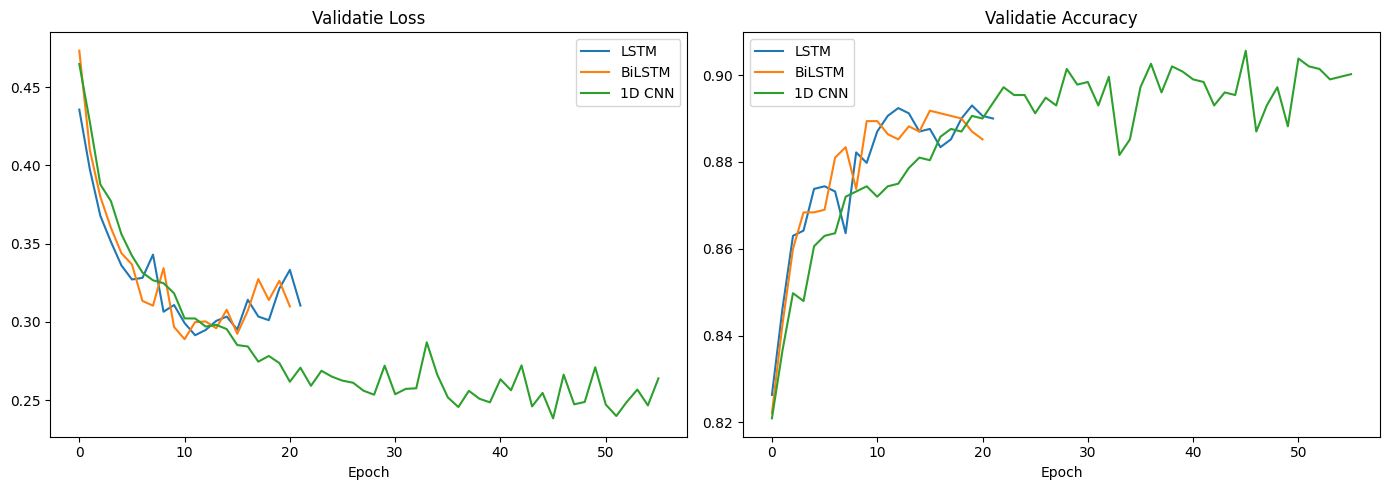

In [19]:
results = pd.DataFrame({
    'Model'      : ['LSTM', 'BiLSTM', '1D CNN'],
    'Val Accuracy': [acc_lstm, acc_bilstm, acc_cnn],
    'Macro F1'   : [f1_lstm,  f1_bilstm,  f1_cnn]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name in [(hist_lstm, 'LSTM'), (hist_bilstm, 'BiLSTM'), (hist_cnn, '1D CNN')]:
    axes[0].plot(hist.history['val_loss'], label=name)
    axes[1].plot(hist.history['val_accuracy'], label=name)

axes[0].set_title('Validatie Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validatie Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Nu gebruiken we de voorspellingen van daarnet om een confusion matrix te zien.

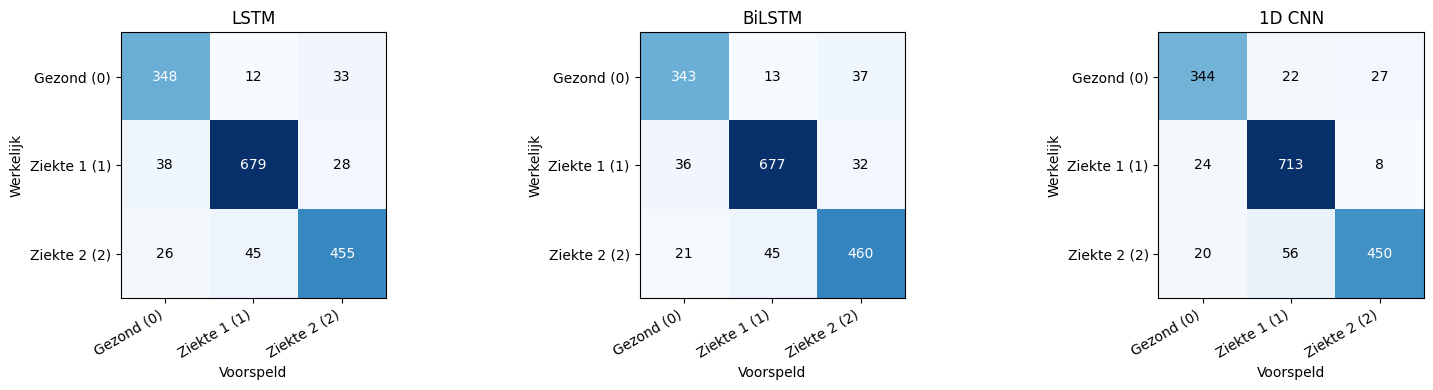

In [20]:
# Confusion matrices naast elkaar
class_names = ['Gezond (0)', 'Ziekte 1 (1)', 'Ziekte 2 (2)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, name in [
    (axes[0], pred_lstm,   'LSTM'),
    (axes[1], pred_bilstm, 'BiLSTM'),
    (axes[2], pred_cnn,    '1D CNN')
]:
    cm = confusion_matrix(y_val, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=30, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Voorspeld')
    ax.set_ylabel('Werkelijk')
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 7. Beste model opslaan

In [21]:
best_f1 = max(f1_lstm, f1_bilstm, f1_cnn)
best_name = ['LSTM', 'BiLSTM', '1D CNN'][[f1_lstm, f1_bilstm, f1_cnn].index(best_f1)]
best_model = {'LSTM': lstm_model, 'BiLSTM': bilstm_model, '1D CNN': cnn_model}[best_name]

print(f"Beste model: {best_name} (Macro F1 = {best_f1:.4f})")

# best_model.save(f"best_model_{best_name.replace(' ', '_').lower()}.keras")
# joblib.dump(scaler, "scaler_lstm_experiment.pkl")
# joblib.dump(le,     "label_encoder_lstm_experiment.pkl")

Beste model: 1D CNN (Macro F1 = 0.8998)


## 8. model testen op testset

Nu zullen we ons model eens testen en een keer kijken naar de bovenste files om te zien of alles werkt.

In [22]:
# df_test_filled = df_test.fillna(0)
# if 'coldPresent_missing' not in df_test_filled.columns:
#      df_test_filled['coldPresent_missing'] = df_test['coldPresent'].isna().astype(int)

# X_audio_test  = []
# X_meta_test = []
# test_ids    = []

# for _, row in df_test_filled.iterrows():
#     cid  = row['candidateID']
#     meta = row[META_COLS].values.astype(np.float32)

#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if os.path.exists(seg_folder):
#         for fname in os.listdir(seg_folder):
#             if fname.endswith("_processed.wav"):
#                 fp = os.path.join(seg_folder, fname)
#                 waveform, _ = librosa.load(fp, sr=16000)
#                 emb_seq = extract_embeddings_sequence(waveform)
#                 X_audio_test.append(emb_seq)
#                 X_meta_test.append(meta)
#                 test_ids.append(cid)

# X_audio_test  = np.array(X_audio_test,  dtype=np.float32)
# X_meta_test = scaler.transform(np.array(X_meta_test, dtype=np.float32))

# y_pred_test = np.argmax(best_model.predict([X_audio_test, X_meta_test]), axis=1)
# y_pred_labels = le.inverse_transform(y_pred_test)

# submission = pd.DataFrame({'candidateID': test_ids, 'disease': y_pred_labels})
# # Aggregeer per kandidaat (meerdere segmenten -> majority vote)
# submission = submission.groupby('candidateID')['disease'].agg(lambda x: x.mode()[0]).reset_index()
# #submission.to_csv('submission.csv', index=False) #TODO csv uncommenten voor je indient.
# print(submission.head())

## 9. Model testen op eigen hoest

Nu zullen we een keer ons beste model testen op een hoest die wij zelf hebben opgenomen.

Hiervoor zullen we eventjes de code nodig hebben uit onze yamnet file.

In [ ]:
def pad_audio(y, target_length):
    if len(y) < target_length:
        padding = target_length - len(y)
        y = np.pad(y, (0, padding), 'constant')
    return y

def truncate_audio(y, target_length):
    if len(y) > target_length:
        y = y[:target_length]
    return y

def adjust_audio(y, target_length=32000):
    if len(y) < target_length:
        return pad_audio(y, target_length)
    else:
        return truncate_audio(y, target_length)

def ensure_sample_rate(original_sample_rate, waveform,
                       desired_sample_rate=16000):
    if original_sample_rate != desired_sample_rate:
        desired_length = int(round(float(len(waveform)) /
                                  original_sample_rate * desired_sample_rate))
        waveform = scipy.signal.resample(waveform, desired_length)
    return desired_sample_rate, waveform

In [ ]:
import numpy as np
from librosa.feature import rms

def segment_cough_sound(signal, sr, cough_threshold=0.05, min_cough_duration=0.1, padding=0.05):

    hop_length = int(min_cough_duration*sr)
    if len(signal.shape) > 1:
        signal = np.mean(signal, axis=1)

    energy = rms(y=signal, hop_length=hop_length)[0]

    normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))

    cough_threshold = np.max(normalized_energy) * cough_threshold
    min_cough_samples = round(sr * min_cough_duration)

    cough_segments = []
    event_start = None

    for i, value in enumerate(normalized_energy):
        if value >= cough_threshold:
            if event_start is None:
                event_start = i*hop_length
        else:
            if event_start is not None:
                cough_duration = i*hop_length - event_start
                if cough_duration >= min_cough_samples:
                    event_end = i*hop_length + int(padding * sr)
                    event_start -= int(padding * sr)
                    event_start = max(event_start, 0)
                    cough_segments.append(signal[event_start: event_end+1])
                event_start = None

    return cough_segments


def process_cough_file(file_path, save_segments=True):
    new_path = file_path.replace(".wav", "_segmented")

    if os.path.exists(new_path) and os.listdir(new_path):
        print(f"Skipping (already segmented): {file_path}")
        return

    try:
        signal, sr = sf.read(file_path)

        if len(signal) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(signal.shape) > 1:
            signal = np.mean(signal, axis=1)

        segments = segment_cough_sound(signal, sr)

        print(f"{file_path} → {len(segments)} segments found")

        if save_segments:
            os.makedirs(new_path, exist_ok=True)
            for i, seg in enumerate(segments):
                seg_path = os.path.join(new_path, f"seg{i}.wav")
                sf.write(seg_path, seg, sr)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")





def process_audio_file(file_path, target_length=32000, desired_sr=16000):
    new_path = file_path.replace(".wav", "_processed.wav")

    if os.path.exists(new_path):
        print(f"Skipping (already processed): {new_path}")
        return

    try:
        waveform, sr = sf.read(file_path)

        if len(waveform) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(waveform.shape) > 1:
            waveform = np.mean(waveform, axis=1)

        sr, waveform = ensure_sample_rate(sr, waveform, desired_sr)

        waveform = adjust_audio(waveform, target_length)

        sf.write(new_path, waveform, sr)
        print(f"Saved: {new_path}")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

Eerst dus onze data klaar maken

In [31]:
process_cough_file("mijn hoest.wav")

process_audio_file("mijn hoest_segmented/seg0.wav")

Skipping (already segmented): mijn hoest.wav
Skipping (already processed): mijn hoest_segmented/seg0_processed.wav


Nu kunnen we het eens testen. Aangezien we gewoon een keer willen zien of het werkt zullen we dit enkel doen op de eerste hoest.

In [32]:
waveform, _ = librosa.load("mijn hoest_segmented/seg0_processed.wav", sr=16000)

emb = extract_embeddings_sequence(waveform) 

emb = emb[np.newaxis, ...] 

# hier zullen we snel eens onze metadata invullen.
# Volgorde: age, gender, tbContactHistory, wheezingHistory, phlegmCough, familyAsthmaHistory, feverHistory, coldPresent, packYears, coldPresent_missing
mijn_meta = np.array([[19, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.float32)
mijn_meta_scaled = scaler.transform(mijn_meta)

pred = best_model.predict([emb, mijn_meta_scaled], verbose=0)
klasse = le.inverse_transform([np.argmax(pred)])[0]
print(f"Voorspelling: {klasse}")
print(f"Kansen per klasse: {dict(zip(le.classes_, pred[0].round(3)))}")

Voorspelling: 0
Kansen per klasse: {np.int64(0): np.float32(0.976), np.int64(1): np.float32(0.024), np.int64(2): np.float32(0.0)}


En zo te zien ben ik inderdaad niet ziek.